# From Manuscript to Machine: Developing an Ottoman Turkish (Naskh) AI Model with Transkribus

### Elif Derin[![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-3412-5664)
Fatih Sultan Mehmet University

### Fatma Aladağ [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-3455-6181) 
Marmara University

[![cc-by](https://licensebuttons.net/l/by/4.0/88x31.png)](https://creativecommons.org/licenses/by/4.0/) ©<AUTHOR or ORGANIZATION / FUNDER>. Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/)


[![cc-by-nc-nd](https://licensebuttons.net/l/by-nc-nd/4.0/88x31.png)](https://creativecommons.org/licenses/by-nc-nd/4.0/) ©<AUTHOR or ORGANIZATION / FUNDER>. Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY-NC-ND](https://creativecommons.org/licenses/by-nc-nd/4.0/)


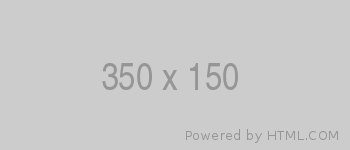

In [6]:
from IPython.display import Image, display

display(Image("./media/placeholder.png"))

Ottoman Turkish manuscripts, Handwritten Text Recognition (HTR), Naskh script, Transkribus, Digital History


This article presents a systematic experimental evaluation of handwritten text recognition (HTR) for Ottoman Turkish manuscripts written in naskh script. Situating the study within recent developments in digital humanities and computational archival science, it examines how paleographic, scribal, and textual variation affect model performance in a Transkribus-based workflow. The analysis is based on a corpus of 160 folios (320 pages) and approximately 90,000 words. The dataset includes not only line-level transcriptions but also structural annotations such as headings, marginalia, catchwords, page numbers, and seals, enabling the separate implementation of layout analysis and HTR processes.

Using a three-stage training design, the study evaluates the impact of incremental data diversification across scribes and texts. The results show that model accuracy is closely related to the structure and heterogeneity of the training data rather than to data volume alone. While the model trained on a single scribe achieved the lowest Character Error Rate (CER), the inclusion of additional scribes and texts led to a non-linear increase in error rates. Qualitative error analysis identifies recurring challenges related to diacritical ambiguity, orthographic variation, and the omission of secondary diacritics.

The study concludes that Ottoman Turkish HTR requires careful consideration of paleographic variation and dataset composition in order to achieve reliable and generalizable results.

## Introduction

Over the past two decades, the digital transformation of manuscript studies has not only democratized scholarly access to collections but also significantly reduced the physical wear of original materials. However, this process —often described as the “first wave of digitization”—has largely focused on the preservation and dissemination of manuscript images. Today, with the rise of Digital Humanities and Computational Archival Science, a second wave of digitization is emerging, one that prioritizes data mining, automated recognition, and advanced analytical processing capacities.

In this context, the digital transformation of Ottoman Turkish is not merely a technical step to facilitate access to historical texts it establishes an interdisciplinary research ecosystem where traditional disciplines such as historiography, philology, and paleography converge under the framework of Digital Humanities. Ottoman Turkish exhibits profound structural complexity due to its “cursive-like” nature —where letter forms vary according to their position— as well as variable baseline alignments and non-standardized orthographic practices. These paleographic challenges, coupled with the lack of a one-to-one correspondence between the original script and the modern Latin alphabet, elevate the task beyond simple transcription into a “multi-layered visual-statistical modeling problem.” Handwritten Text Recognition (HTR) technology addresses this by analyzing text at the line level through a statistical pattern recognition approach, integrating visual form and linguistic continuity into a coherent framework that transforms Ottoman archives into “collections as data” (### UNKNOW REF NOT FOUND).


In recent years, advances in AI-based text recognition technologies have made it possible to incorporate manuscript materials into machine learning workflows. In particular, the Transkribus platform offers a functional research environment for historians and scholars in the humanities by enabling the training of custom models on user-provided data without requiring programming expertise (<cite id="xe46r"><a href="#zotero%7C13846739%2F2YHPXY4K">(Aladağ &#38; Derin, 2023)</a></cite>).

The integration of features such as line segmentation, layout analysis, custom HTR model training, and export in TEI/PAGE XML formats allows historical manuscripts to be transformed into data that is not only readable but also computationally analyzable.

This study represents a step toward rendering Ottoman Turkish manuscripts written in the naskh (*nesih*) script digitally processable. Through a three-stage training strategy applied to Ottoman naskh manuscripts, the article presents one of the first quantitative assessments demonstrating that scribal and textual diversity affect HTR error rates in a non-linear manner. The model developed on the Transkribus platform integrates both automatic transcription (HTR) and layout recognition functionalities and was trained on a corpus comprising 160 folios (320 pages) and approximately 90,000 words produced by multiple scribes.

During the training process, not only text lines but also structural elements such as headings, columns, marginal annotations (*derkenar*), page numbers, and seals were annotated. This approach reflects an explicit methodological aim to model not merely character recognition, but also the formal and codicological features intrinsic to Ottoman manuscript culture.


## HTR Technologies in Historical Documents: Developments and Research Implications

Deep learning–based Handwritten Text Recognition (HTR) systems have brought about a major transformation in the digitisation of historical documents over the past decade. In particular, Europe-based projects have established large-scale datasets for Gothic, Kurrent, and Latin scripts, thereby defining the practical accuracy limits of HTR models and introducing a comparable evaluation standard based on the Character Error Rate (CER). Within this framework, the literature has also identified threshold values indicating when automated recognition becomes meaningful and efficient for scholarly use. Hodel characterises a CER of 12% as a critical threshold at which automated transcription becomes more economical and time-efficient than manual transcription (Hodel 2020 ### REF NOT FOUND). Similarly, the Transkribus platform considers CER values of 10% or below to represent efficient and practically usable results for automated transcription. Against these benchmarks, the general model developed by Hodel et al. (<cite id="k60xf"><a href="#zotero%7C13846739%2FDV8SRZ7H">(Hodel et al., 2021)</a></cite>) for German Kurrent, achieving a CER in the range of 2–5%, demonstrates an exceptionally high level of accuracy for historical material.

The primary environment in which these accuracy thresholds and evaluation criteria have been translated into research practice has been the Transkribus platform. Mühlberger et al. (<cite id="in0gd"><a href="#zotero%7C13846739%2F5YTILZ66">(Muehlberger et al., 2019)</a></cite>) describe Transkribus as a turning point in archival research, emphasizing that the ability for users to generate their own datasets and develop customised models has transformed historical manuscript recognition into a practical research tool. However, the majority of these models have been developed for Latin-based writing systems; consequently, the platform's technical infrastructure was adapted to Arabic-script writing systems at a relatively late stage (<cite id="qj1ip"><a href="#zotero%7C13846739%2FFJBA3R37">(Nockels et al., 2022)</a></cite>).

The challenges encountered in developing HTR models for Arabic-script manuscripts stem not so much from the general structural characteristics of the writing system itself, but rather from how these characteristics are reflected in automated recognition processes. In Ottoman Turkish manuscripts, letterform variation depending on position within the word, the absent or irregular use of diacritics or dots, fluctuations in baseline alignment, and divergent scribal practices all contribute to cumulative errors, particularly at the stages of line segmentation and character-level alignment. Consequently, models developed for Ottoman Turkish must be trained not merely to recognize Arabic-script writing in general, but to learn visual patterns specific to a particular script type and manuscript practice.

This requirement also intersects with a broader structural issue identified by Nilsson-Fernàndez and Dombrowski (### REF NOT FOUND) in the context of multilingual digital humanities. As the authors argue, Latin-centered digital infrastructures and text-processing tools are built upon a limited set of assumptions that do not readily accommodate right-to-left (RTL) and context-sensitive writing systems. The challenges encountered during model training for Ottoman Turkish manuscripts within the Transkribus environment can therefore be understood as a practical manifestation of this structural mismatch. Within the technical framework provided by the platform, the deliberate selection of training data, annotation strategies, and modeling decisions tailored to Ottoman Turkish thus becomes a methodological necessity rather than a purely technical preference.

Beyond the challenges shared by RTL languages more generally, Ottoman Turkish introduces an additional layer of complexity in HTR workflows. While HTR models for Arabic-script languages typically operate within a single writing system, Ottoman Turkish studies often involve a two-layered process: the visual recognition of the Arabic-script text, followed by its transfer into a Latin-based writing system. This dual transformation renders Ottoman Turkish distinctive not only in paleographic terms but also with respect to its output format when compared to other Arabic-script languages.

Ottoman Turkish constitutes a hybrid linguistic structure characterized by vocabulary inherited from Arabic and Persian, an agglutinative Turkish morphology, and historically contingent orthographic conventions that exhibit a high degree of internal variation. As a result, the HTR process must address more than the recognition of letterforms alone; it requires a modeling approach that is sensitive to historical context, scribal norms, and transliteration principles. Digital text recognition in Ottoman Turkish should therefore be understood as a multi-layered process that simultaneously engages with the contextual complexity of Arabic-script writing systems and the philological and epistemological implications of transferring historical texts into a modern Latin-based script.


## Rationale for Tool Selection

In HTR projects, data management constitutes a methodological stage as decisive as model training itself. The FAIR principles (Findable, Accessible, Interoperable, Reusable) emphasize long-term reusability and structural transparency of research data (<cite id="z4p6h"><a href="#zotero%7C13846739%2FPDX39T8Q">(Wilkinson et al., 2016)</a></cite>), while the CARE principles foreground issues of data ownership, representational responsibility, and community-oriented access in cultural heritage contexts (<cite id="z3lzs"><a href="#zotero%7C13846739%2FQKCTZ6VD">(Carroll et al., 2020)</a></cite>).

In projects dealing with Ottoman Turkish manuscripts, these principles operate less as abstract ethical frameworks than as concrete criteria shaping tool selection, data workflows, and dissemination strategies. Accordingly, tools must be evaluated not only in terms of recognition accuracy, but also with respect to whether they enable sustainable access, reuse, and circulation of HTR data within the scholarly community.

In this study, the selection of the Transkribus platform is directly related to its ability to meet these criteria in a particularly functional and sustainable manner. Transkribus shifts the process of model training away from a closed domain of technical expertise by enabling users to develop custom HTR models based on their own ground truth data, to make these models publicly accessible, and to allow other researchers to further refine them through fine-tuning.

The hybrid architecture offered by the platform enables anonymized transcription data uploaded by users to be processed on centralized servers, while simultaneously allowing individual researchers to retain control over their own datasets. This balance renders Transkribus a viable option for fields such as Ottoman Turkish studies, where both philological sensitivity and data privacy are critical concerns. The methodological framework proposed by Romein et al. (<cite id="zdwpl"><a href="#zotero%7C13846739%2FRBAR8ING">(Romein et al., 2025)</a></cite>)  for the Transkribus community further demonstrates how model sharing, data management, and community-driven reuse can be sustained within this platform.

Another determining factor in the choice of Transkribus is the adaptability of its technical outputs to diverse research objectives. The platform is not limited to producing automatic transcriptions; it also integrates page layout analysis, structured tagging, export in standardized formats such as PAGE XML and ALTO XML, and the generation of rich metadata suitable for digital scholarly editions. This integrated functionality allows Ottoman manuscripts to be treated not merely as readable texts, but as analyzable and reusable digital objects.

The publication of the trained model through the Transkribus Public Models interface, together with the dissemination of the ground truth dataset in open formats (UTF-8, PAGE XML) via the HTR-United collective’s GitHub repository, was deliberately designed as a complementary strategy to mitigate platform dependency. In this configuration, Transkribus —despite being a proprietary environment— is embedded within a research workflow that remains compatible with principles of open data and reproducibility. Consequently, the choice of platform should not be understood solely as a decision based on technical capability, but rather as part of a broader methodological commitment to developing a sustainable, shareable, and community-oriented HTR practice for Ottoman manuscript studies.

## Construction of the Dataset

The construction of the training dataset was designed to account simultaneously for the paleographic diversity of the Ottoman Turkish manuscript tradition and the learning dynamics of HTR models. This study constitutes a direct continuation of the Printed Ottoman Turkish HTR Model developed by Kırmızıaltın, Aladağ, and Derin (<cite id="mxfeo"><a href="#zotero%7C13846739%2F2YHPXY4K">(Aladağ &#38; Derin, 2023)</a></cite>). The high accuracy achieved by that model on printed texts —approximately 93%— demonstrated the structural compatibility of the Ottoman writing system with machine learning approaches and provided a solid methodological foundation for extending HTR research from printed material to handwritten sources. Building on this foundation, the present study represents one of the first systematic attempts to transfer Ottoman Turkish HTR from print to manuscript culture.

Experiments conducted with the printed-text model showed that learning curves progressed in a relatively stable and predictable manner, largely due to the formal consistency of letterforms. For this reason, the transition from printed texts to manuscripts required a strategic selection of script. Naskh (nesih) script was chosen as the initial focus of the dataset, as it exhibits the strongest formal parallels to printed Ottoman Turkish in terms of legibility, regularity of letterforms, and line structure. The initial dataset was therefore constructed around manuscript material written in naskh, enabling a controlled transition from typographic to handwritten variation.

At the end of the initial training phase, it became evident that while the model achieved high accuracy on data produced by a single scribe, its performance declined noticeably when applied to a different copy of the same work or to manuscripts written by other hands. This pattern indicates that the model had begun to internalize scribal idiosyncrasies rather than the more general characteristics of the writing system. In response to this finding, the dataset was deliberately expanded to include multiple copies of the same work produced by different scribes. This expansion allowed the model to learn variation not only at the level of individual lines but also at the level of manuscript production practices. Within this framework, the dataset was conceived not as the transcription of a single text but as a multi-layered data pool designed to represent the paleographic and variational diversity of the Ottoman manuscript tradition, ensuring that the model would develop a generalizable learning capacity rather than a narrowly scribe-specific behavior.



This methodological choice is consistent with recent findings in the literature. Reshef and Gutschow (<cite id="6go4x"><a href="#zotero%7C13846739%2FLT4Q29IG">(Reshef &#38; Gutschow, 2024)</a></cite>) demonstrate that in writing systems characterized by contextual and formal variability, multi-source datasets lead to statistically significant improvements in model robustness. In the case of Ottoman Turkish —an underrepresented writing system marked by extensive ligature use, context-dependent letterforms, inconsistent dotting practices, and a hybrid Arabic–Persian lexicon— multi-scribal dataset design is not merely a practical enhancement, but a methodological necessity for sustainable HTR performance.

The size of the initial training dataset was informed by existing methodological benchmarks while remaining sensitive to the specific challenges posed by Ottoman Turkish. Previous work on Transkribus-based HTR workflows suggests that approximately 10,000 words may suffice to train an individual HTR model under controlled conditions, particularly for scripts with relatively stable graphic conventions (Hodel 2020 ### REF NOT FOUND; <cite id="zoq8a"><a href="#zotero%7C13846739%2FRBAR8ING">(Romein et al., 2025)</a></cite>). However, this threshold should be understood as a minimum viable scale rather than an optimal standard. Given the paleographic heterogeneity and linguistic complexity of Ottoman Turkish manuscripts, the present study deliberately exceeded this baseline.

Beyond dataset composition, the methodological architecture of the training pipeline required explicit control over the structural organization of manuscript pages. Although the layout analysis model trained in this study does not directly affect the Character Error Rate (CER) of the HTR model, it plays a critical role in the overall transcription workflow by preventing marginalia, catchwords (*reddādes*), page numbers, and other paratextual elements from being conflated with the main text. When HTR is applied to full-page images or generic layout models are used, such elements typically require extensive manual correction. By contrast, the custom layout model developed for this study enables controlled segmentation in which only main-text regions are selected for HTR processing, reducing noise in the input data and minimizing manual intervention. The functional separation of layout analysis and text recognition thus supports a cleaner and more reproducible training and inference pipeline, while preserving codicological information as an independent analytical layer.
<!-- #endregion -->

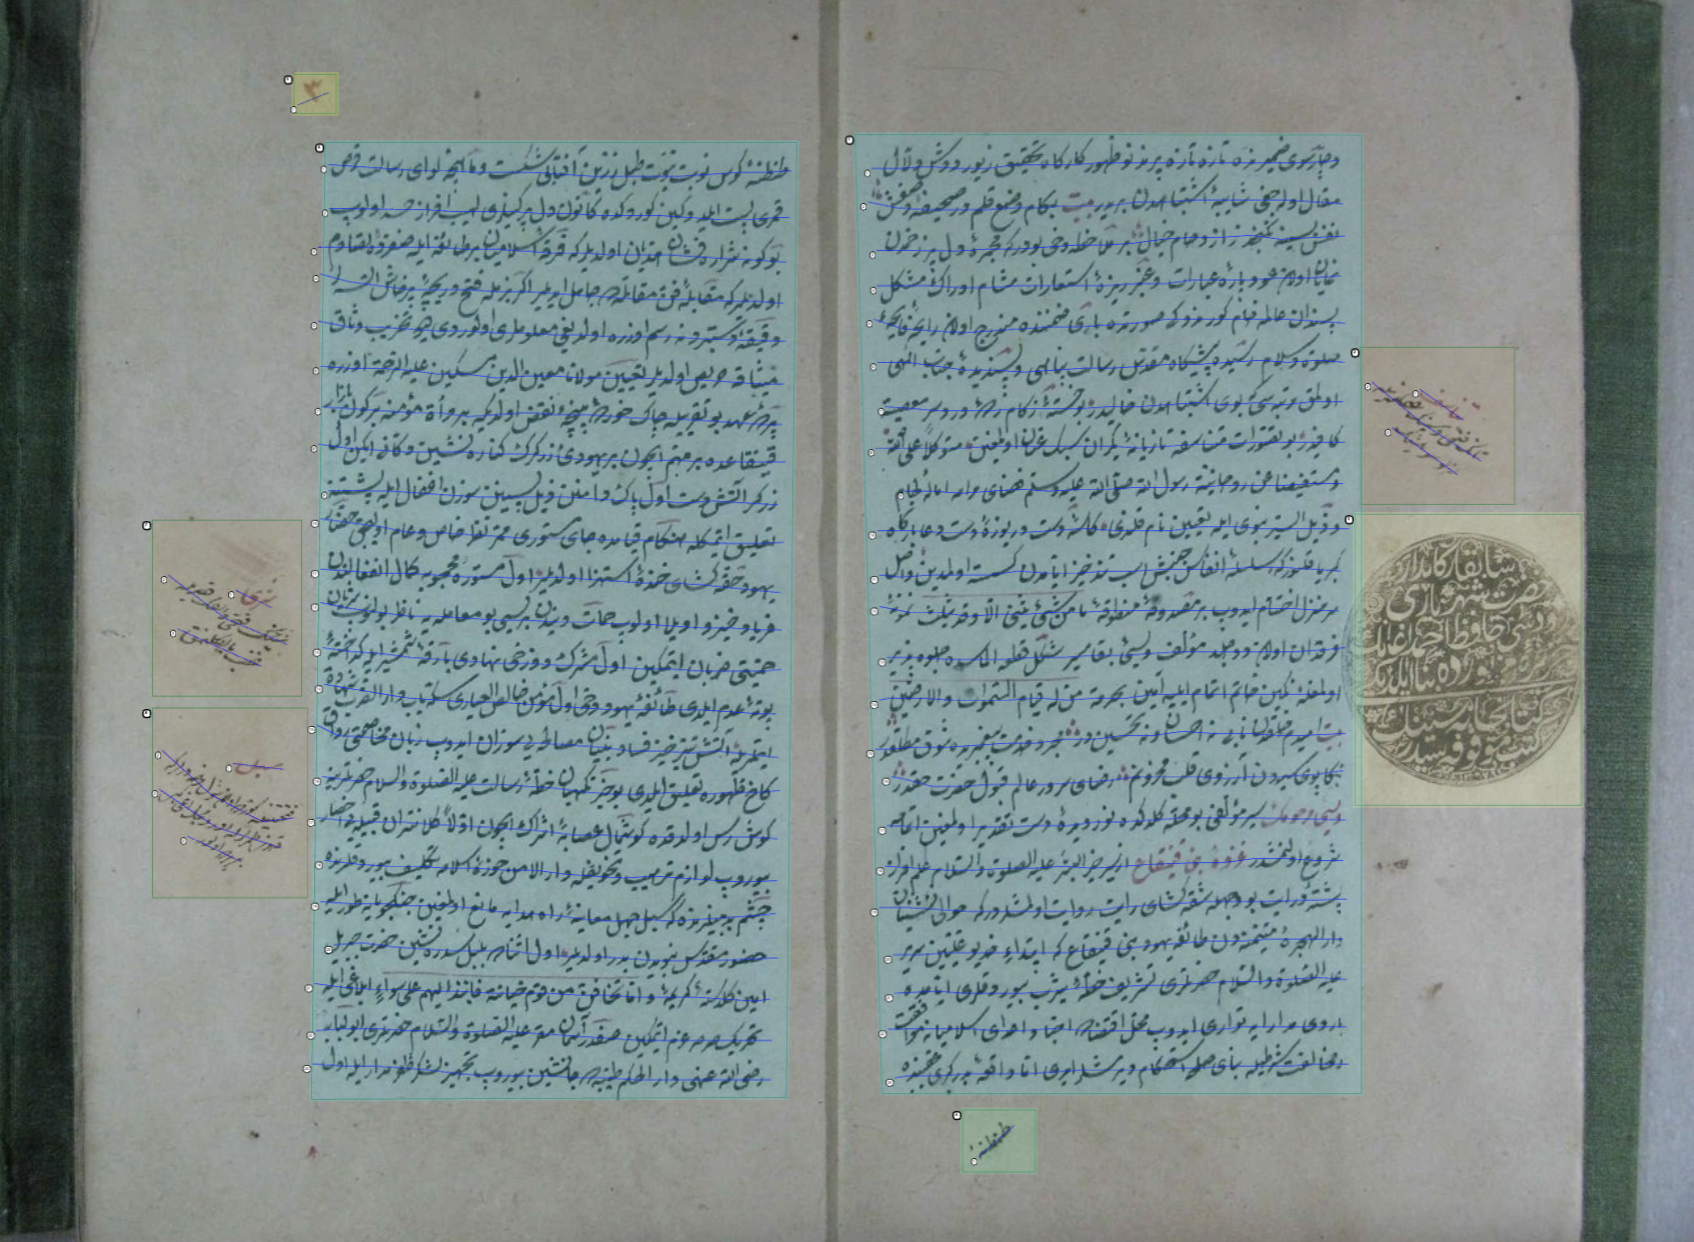

In [5]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Layout analysis output showing the automatically detected and labeled page regions"
            ]
        }
    }
}
display(Image("figures/fig01_layout_analysis.png"), metadata=metadata)

The initial model experiment was conducted on a dataset comprising 125 manuscript pages and 78,628 words. While this volume proved sufficient for learning the core formal characteristics of the naskh script, it remained limited when evaluated against the broader scribal and period-based diversity of Ottoman manuscript culture. Consequently, the model development process was structured not merely around increasing data quantity, but around incrementally expanding data diversity.

Two primary factors guided this expansion strategy: (1) paleographic variation, including differences in scribal practice and letter formation; and (2) linguistic variation, encompassing vocabulary density, period-specific usage patterns, and genre-dependent textual structures.

Accordingly, subsequent training stages incorporated additional samples produced by different scribes and representing distinct textual genres, reducing the risk of early overfitting to a single writing style while enhancing the model’s applicability to heterogeneous manuscript material.

All manuscripts were transcribed using a Unicode (UTF-8) character set to ensure character-level consistency. Transcription followed IJMES transliteration conventions rather than modern Turkish orthography, in line with established practices in Ottoman digital humanities research. This decision supported stable character-level learning during model training while ensuring that the resulting data remain reusable for philological research and interoperable with NLP pipelines, AI-based analytical tools, and digital scholarly edition platforms.

The initial training phase relied on a seventeenth-century sīra text written in naskh script, *Meʿālim al-Yaqīn fī Sīrat Sayyid al-Mursalīn* by Bâkî (composed in 1539). Two manuscript copies of this work were used: one preserved in the Nuruosmaniye Library (no. 3260, undated) and another in the Süleymaniye Library, Hamidiye collection (no. 402), copied in 1599. Their combined use enabled the model to learn paleographic variation across two different scribal hands within the same textual tradition.

In the third training phase, the dataset was expanded with *Ḥadāʾiq al-Shaqāʾiq* by Majdī Meḥmed Efendi, a translation and expanded adaptation of Taşköprüzāde Aḥmed Efendi’s *al-Shaqāʾiq al-Nuʿmāniyya*, composed in 995/1586–87. This work—characterized by dense scholarly prose, extensive use of formal titles, and a high concentration of Arabic–Persian compounds—was included to test the model’s capacity for both linguistic and paleographic generalization. The manuscript used is preserved in the Rodos Ḥāfiẓ Aḥmed Ağa Library (*Terceme-i Shaqāʾiq al-Nuʿmāniyya*, no. 1185), copied in 1016/1607–08.

As summarized in Table 1, the combined use of these texts follows a principle of incremental diversification: initial learning from a single scribe, adaptation to scribal variation within the same work, and finally generalization across different texts and scribes. This strategy supports the overarching goal of moving beyond a model tailored to a single manuscript or hand toward the development of a Naskh HTR infrastructure applicable across a broader range of Ottoman manuscripts.

| **Training Phase** | **Source Text** | **Type of Variation** | **Role in the Model** |
|----|----|----|----|
| Phase 1 | *Meʿālim al-Yaqīn* | Single scribe | Baseline learning (letter forms, line structure) |
| Phase 2 | *Meʿālim al-Yaqīn* (second copy) | Same text, different scribe | Adaptation to scribal variation |
| Phase 3 | *Ḥadāʾiq al-Shaqāʾiq* | Different text and different scribe | Genre- and language-level generalization |

## Model Architecture and Training Process


The HTR model in this study was trained in Transkribus using the HTR+ (CNN–LSTM) architecture. As an initial experiment, a transfer-learning strategy was applied by initializing training from our previously released Printed Ottoman Turkish model, with the expectation that prior exposure to Arabic-script letterforms would accelerate convergence on naskh manuscripts. However, empirical results showed limited transferability across the print–manuscript domain.

This limitation can be attributed to fundamental qualitative differences between the two data domains. The printed model is based on nineteenth- and twentieth-century periodicals, whereas the manuscript material examined here reflects sixteenth- and seventeenth-century scribal practices. Differences in period-specific language use, line structure, scribal conventions, and lexical composition outweighed superficial similarities in letter shapes, preventing effective knowledge transfer.

These findings indicate that model performance in Ottoman Turkish HTR is determined less by architectural choice or pretraining strategy than by the representativeness and internal structure of manuscript ground truth data. Accordingly, the present study foregrounds data composition, scribal variation, and genre diversity as primary methodological variables shaping recognition accuracy, rather than relying on transfer learning across historically and materially distinct domains.

## Model Training Strategy: The Separation of Layout Analysis and HTR Processes

In this study, the model development workflow was structured around two functionally distinct training pipelines: page layout analysis and automatic handwritten text recognition (HTR). Although both processes rely on the same corpus of Ottoman manuscript material, they produce different types of outputs and serve different analytical purposes. For this reason, their training designs were deliberately separated (Figure 2).

The layout model was designed to classify the codicological and spatial structure of the manuscript page. It identifies and distinguishes between structural components such as the main text block, headings, catchwords, marginal notes (*marginalia*), page numbers, and seals. Unlike the HTR model, the layout model does not generate textual transcriptions; instead, it performs visual segmentation and preserves the multi-layered page organization of the manuscript in a machine-readable form. It should be noted that the layout model does not operate independently of the tagging process; rather, it learns to generalize the structural distinctions that were first introduced through manual layout annotation. While layout recognition does not directly determine HTR accuracy, it plays a crucial supporting role by facilitating data cleaning and enabling the systematic separation of the primary text from paratextual elements. At the same time, layout outputs constitute an independent analytical layer that can be reused for research focusing on the material, codicological, and spatial properties of Ottoman manuscripts.

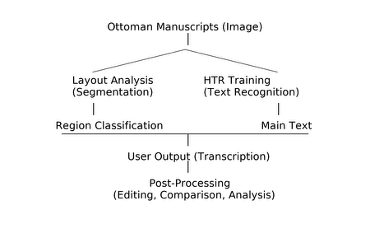

In [8]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Workflow of the Ottoman Turkish HTR pipeline"
            ]
        }
    }
}
display(Image("figures/fig02_workflow.png"), metadata=metadata)


The HTR model, by contrast, was trained exclusively on main-text lines. Marginalia, corrections (*taṣḥīḥ* marks), and other paratextual elements were deliberately excluded from the initial training phase due to their paleographically irregular and linguistically heterogeneous character. This decision enabled a more controlled learning environment in which the model could acquire core graphical features —such as letter shapes, line structure, and punctuation patterns— from a relatively stable data domain. As a result, the early stages of training focused on establishing a robust baseline for formal recognition before introducing additional layers of variability.

During model training, Transkribus’s built-in automatic pretraining mechanism was active. This feature initializes training with parameter values derived from existing Ottoman Turkish models available on the platform. Importantly, this process does not constitute manual transfer learning; rather, it is part of Transkribus’s default training protocol. While the model therefore did not need to learn low-level representations of the writing system from scratch, the period-specific, linguistic, and paleographic characteristics of the handwritten data were learned anew. This distinction is methodologically significant, as it underscores both the advantages and the limits of platform-supported pretraining in the context of early modern Ottoman manuscript material.

The training strategy was based on a principle of incremental data expansion. In the first stage, the model was trained on lines produced by a single scribe, allowing it to internalize core graphical features such as letter forms, diacritic placement, and line flow.

In the second stage, lines taken from a copy of the same work transcribed by a different scribe were incorporated into the training set. This expansion enabled the model to adapt to variability in handwriting style while maintaining consistency at the textual and genre level.

In the third stage, additional data were introduced from a different work written in *nesih* script and copied by a third scribe. This step tested the model’s capacity to generalize beyond purely formal variation, extending its learning to encompass period-specific, generic, and linguistic diversity. Through this staged approach, the model was progressively exposed to increasing levels of complexity, reflecting the heterogeneous nature of Ottoman manuscript production.

This approach prevented the model from remaining a narrowly scoped system tailored to a single manuscript or scribe, instead enabling the development of an HTR infrastructure with broader applicability across the Ottoman manuscript tradition, grounded specifically in the *nesih* script.

## Tagging Strategy and PAGE XML Structure

The tagging strategy described in this section constitutes the epistemic and technical foundation of the layout analysis discussed above, as these structural annotations provide the training data through which layout distinctions are learned by the model. The tagging process carried out before model training was designed not only to produce line-based transcriptions, but also to render the structural information inherent to the page layout of Ottoman manuscripts machine-learnable. Ottoman manuscripts do not consist of a linear flow of text; rather, they exhibit a complex, multi-layered codicological structure that includes main text blocks, marginal notes (*derkenar*), correction marks, catchwords, headings, seals, and page numbers. For this reason, the dataset was processed using a multi-layered tagging strategy that simultaneously accounts for textual content and page-level structural relationships.

Within this framework, the components present on the manuscript page were defined as separate categories, including main text lines, headings, catchwords, marginalia, page numbers, and seals or other visual elements. This differentiation enables a digitally separable representation of the multi-layered page layout commonly encountered in Ottoman manuscripts. As a result, the model is not limited to recognizing textual content alone but is also able to learn the spatial positioning and functional organization of text elements across the page.

This choice was evaluated not as a technical necessity but as a methodological requirement. At the optical level, all of these elements are perceived by the machine as components of the same writing system; when the model is exposed to a uniform text flow, marginalia, correction marks, or catchwords may be interpreted as a continuation of the main text. This leads not only to increased error rates in HTR output but also to a greater need for data cleaning in subsequent philological and analytical workflows. Explicitly teaching layout information to the model is therefore intended to prevent such errors and to support the production of cleaner and more analytically reliable outputs.

The tagging processes were recorded using the PAGE XML standard, which is widely employed in the digital humanities. PAGE XML provides a robust and flexible data structure for HTR models, as it allows line boundaries, region coordinates, component types, and transcription data to be stored together within a single framework. All transcriptions were encoded in Unicode (UTF-8), ensuring explicit representation of letters, diacritics, and composite characters. This approach guarantees that the resulting dataset is not only usable within the Transkribus environment but also reusable and machine-processable across different platforms.

In conclusion, this tagging approach makes it possible to incorporate the complex structural characteristics of Ottoman manuscripts into the modeling process while maintaining transcription accuracy, thereby producing a modular, sustainable, and reusable digital representation. This structure enables HTR outputs to be treated not merely as readable texts, but as analytical data objects that can be employed across a wide range of digital humanities applications.


## Three-Stage Model Training and Performance Comparison


The model development process was conducted using a three-stage training design to examine the impact of data diversity and scribal variation on HTR performance. This approach aims not only to compare final accuracy rates but also to quantitatively document how paleographic and textual variation specific to Ottoman manuscripts manifests itself within machine learning models. The key parameters of the three training cycles are presented in Figure 3.



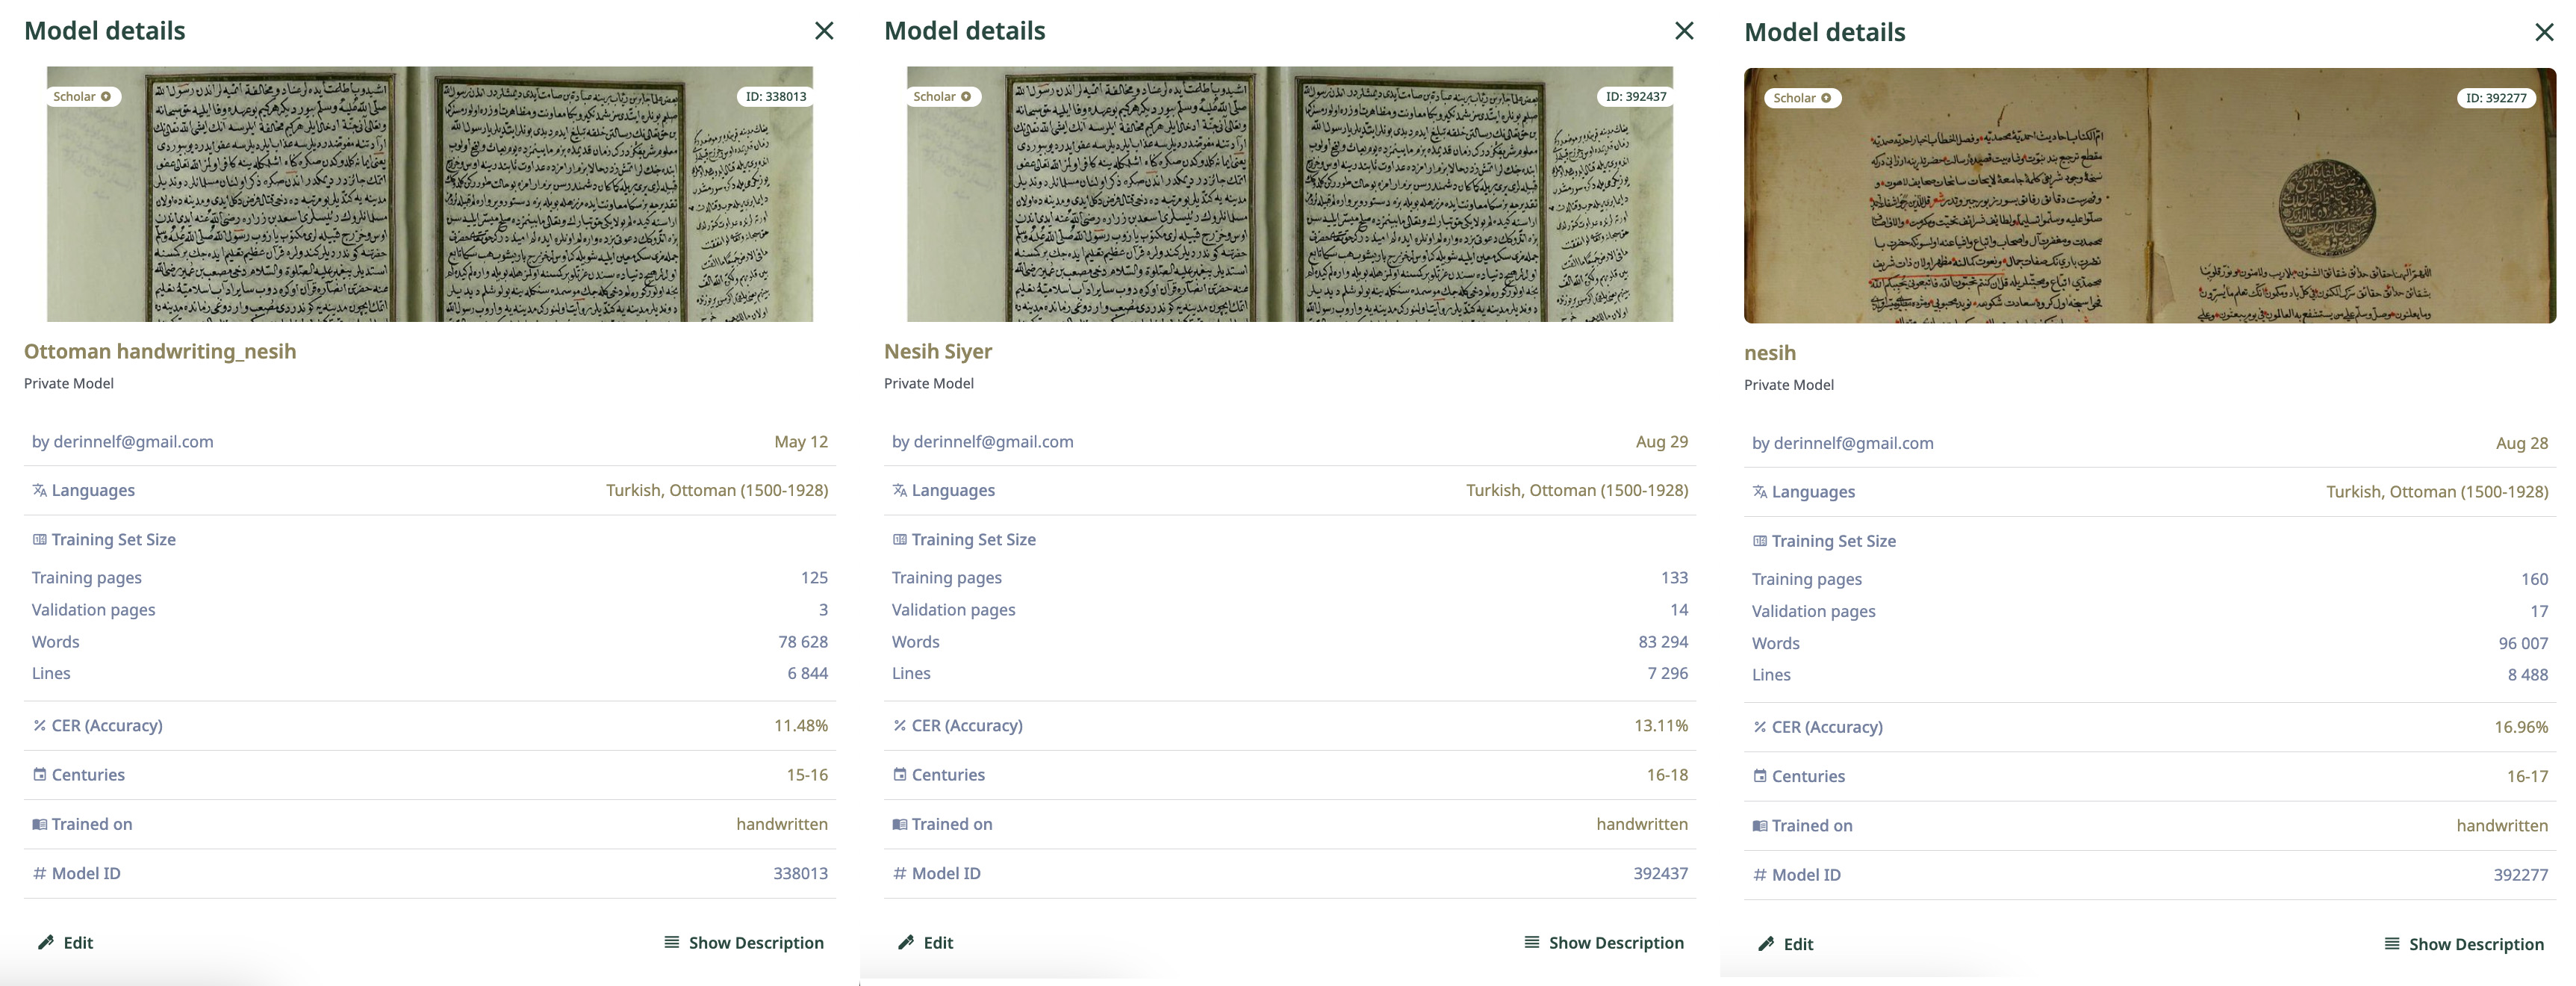

In [9]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Training configuration and CER values for the three HTR models"
            ]
        }
    }
}
display(Image("figures/fig03_training_configuration.jpg"), metadata=metadata)

In the first stage, the model was trained on lines produced by a single scribe and achieved the lowest error rate (11.48% CER). This result demonstrates that graphical patterns —such as letter forms, dot placement, word spacing, and line rhythm— can be learned rapidly under a consistent scribal hand, indicating that at this stage the model internalized the script as a “singular and stable system.”

In the second stage, the model’s capacity to adapt to scribal variation was tested by adding a second copy of the same work produced by a different scribe. The increase in the error rate to 13.11% reveals paleographic variation as a critical inflection point for model performance. Variations in letter forms, dot configurations, word ligation, and individual differences in line flow were interpreted by the model as new feature sets, significantly complicating the learning process.

In the third stage, the model was expanded not only with data from a new scribe but also with a different work and a distinct lexical profile. The simultaneous increase in both scribal and textual diversity resulted in a further rise in the error rate to 16.96%. This outcome supports two key methodological implications.

1.  Paleographic diversity (variation in writing style) exerts a substantially stronger impact on model performance than textual diversity. Differences originating from individual scribes —particularly in letter forms, dotting conventions, and line rhythm— constitute the primary challenges of the visual learning process.

2.  Although the model can achieve high accuracy within a single writing style, effective generalization across multi-scribal datasets clearly requires a larger and more balanced volume of training data.

The transcription process in Ottoman Turkish is inherently two-layered, involving both visual decoding (the recognition of letter forms) and transfer into the Latin alphabet (translation/transliteration), which further reinforces this finding. Each newly introduced script and content type introduces not only optical but also linguistic variation, thereby forcing the model into a new learning cycle.

When these three stages are considered together, a structural characteristic of Ottoman Turkish HTR research becomes evident: model accuracy is more strongly correlated with the homogeneity of the data than with its sheer volume. Consequently, working with multi-scribal datasets that span different periods and incorporate diverse copying practices requires longer training cycles, more extensive ground truth production, and more advanced fine-tuning strategies.

The findings demonstrate that while the model achieves high accuracy when trained on a single, internally consistent writing style, performance does not decline linearly as the historical diversity of manuscript culture increases. Instead, it follows a threshold-based and discontinuous pattern. This clearly indicates that model training for Ottoman manuscripts is not a linear process; rather, at each stage where data diversity expands, the model is compelled to undergo a renewed learning phase.


## Qualitative Error Analysis and Paleographic Challenges

Although the model achieved a low Character Error Rate (CER), a qualitative inspection reveals specific patterns of misinterpretation rooted in the paleographic characteristics of the naskh script. As illustrated in Figure 4, these errors can be categorized into three main groups:

1.  Diacritical Ambiguity (Dot Placement): The model occasionally confuses letters that share the same skeletal structure (rasm) but differ in dot placement. For instance, distinguishing between Ra (ر) and Za (ز), or Ta (ت) and Tha (ث), becomes problematic when the diacritical dots are faint, physically damaged, or written with irregular spacing.

2.  Vocalization and Orthographic Polyvalence: A significant challenge arises from the inherent polyvalence of the Ottoman script, particularly regarding vowel representation. The model struggles with ambiguous orthography, where a single grapheme can represent multiple phonemes depending on the context. A recurring example is the misreading of implied vowels, such as transcribing the word forms like ide vs. ede, or incorrectly inferring the phonetic value of the letter Waw (و) or Ya (y) in the absence of explicit vocalization marks.

3.  Omission of Secondary Diacritics (Gemination): While the base characters are generally recognized correctly, the model frequently overlooks auxiliary diacritics such as the *shadda*. This leads to “gemination errors,” where a double consonant is transcribed as a single one (e.g., failing to recognize the emphasis in Arabic loanwords), effectively altering the morphological structure of the word

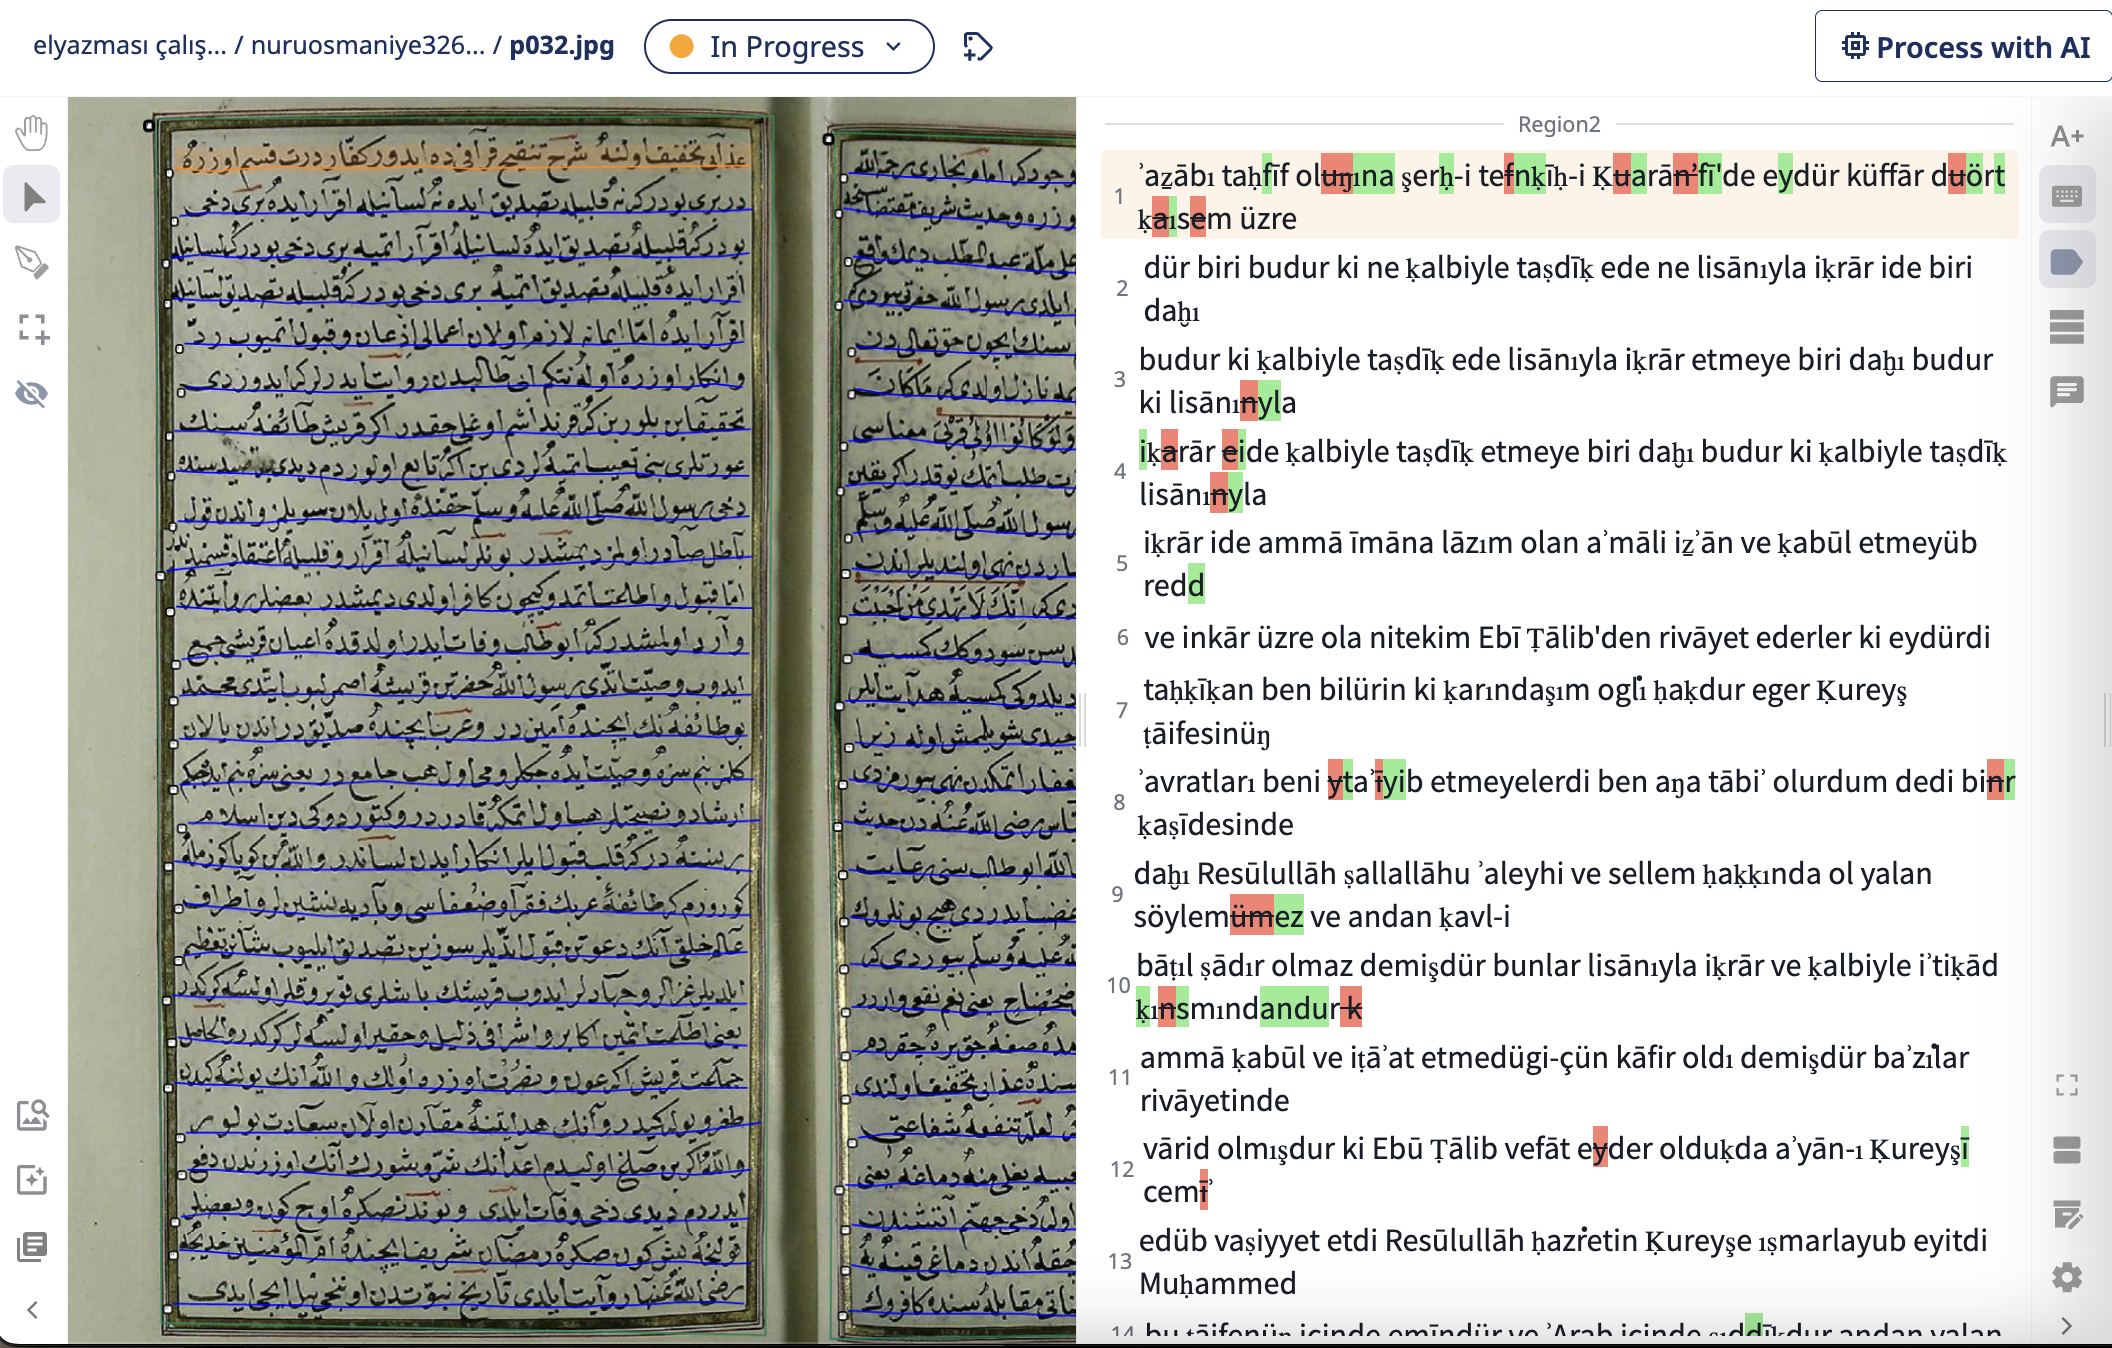

In [14]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Comparative visualization of transcription errors"
            ]
        }
    }
}
display(Image("figures/fig04_comperative_visualisation.png"), metadata=metadata)

These errors indicate that while the HTR model is highly proficient at recognizing character shapes, it still lacks the semantic and morphological contextual awareness required to fully resolve the ambiguities of Ottoman Turkish orthography.

These persistent error patterns highlight a critical divergence regarding data efficiency between Ottoman Turkish and other scripts. While relatively smaller datasets often suffice for training effective HTR models in Latin-based languages, our findings suggest that Ottoman Turkish handwriting is significantly more “data-hungry.” Although the initial model trained on a homogeneous (single-scribe) dataset yielded acceptable error rates, the expansion to a heterogeneous (multi-scribe) dataset did not immediately result in the same level of accuracy. This indicates a non-linear relationship between data variety and model performance in the context of Ottoman paleography. Therefore, to achieve an “economically acceptable” error rate —where the cost of manual post-correction does not outweigh the benefits of automation— for generalized models, the Ground Truth data pool requires substantial expansion beyond what is typically required for simpler scripts.


## Limitations

This study constitutes one of the first experimental attempts to assess the feasibility of developing an HTR model for Ottoman Turkish written in naskh script and to quantitatively document the relationship between data diversity and model accuracy. The three-stage training design demonstrates that model performance is closely tied not only to the technical architecture but also to the structure of the training data, scribal diversity, and the linguistic properties of the texts. In particular, the fact that the initial model trained on a single scribe and a single work achieved the lowest error rate indicates that scribal idiosyncrasy is a decisive variable shaping HTR performance in Ottoman manuscripts. By contrast, the inclusion of additional scribes and different works increased paleographic and linguistic variation, leading to a gradual decline in accuracy. These findings suggest that large-scale Ottoman Turkish HTR models require not merely more data, but a carefully balanced data architecture that explicitly accounts for variation across scribes, texts, and linguistic registers.

An examination of the model outputs shows that accuracy does not display a homogeneous distribution at the line level: while full accuracy is achieved in some lines, distinct clusters of errors emerge in others, particularly within specific structural components. This indicates that the model’s learning behavior is sensitive to context, line layout, and writing density, and suggests that future improvements may be achieved through layout-aware decoding, title–main text separation, the integration of language models, and LLM-based post-processing strategies.

The limitations of this study can be assessed on three levels. First, the volume and diversity of the training data remain experimental in scale and do not fully represent the broad, generically and chronologically heterogeneous production landscape of Ottoman manuscripts. Second, although the works included in the dataset share the same script type (naskh), they exhibit differences in linguistic density, genre, and period-specific usage; this variability constitutes a significant factor limiting the model’s capacity for generalization. Third, the model operates solely at the level of visual recognition and is not integrated with secondary-stage processes such as linguistic normalization, contextual validation, or morphological control. As a result, the generated transcriptions do not always constitute philologically consistent texts, and output quality remains susceptible to context-independent, isolated character-level errors.

Despite these limitations, the study offers an important methodological roadmap for the development of more comprehensive HTR models for Ottoman Turkish. The findings demonstrate that achieving high-accuracy HTR is not merely a matter of technical optimization; rather, it constitutes a philological process that requires the systematic modeling of the historically accumulated diversity of Ottoman writing culture, scribal practices, and period-specific orthographic norms. Accordingly, future research is expected to move toward the development of scribe-based sub-model families, the stratification of datasets reflecting chronological variation, the creation of genre-specific specialized models, and the integration of LLM-assisted post-processing layers into HTR workflows. In addition, the establishment of large-scale open data infrastructures and the wider adoption of community-based ground truth production will play a critical role in ensuring the long-term sustainability of progress in this field.

In conclusion, this study demonstrates not only that HTR models for Ottoman Turkish manuscripts are feasible, but also that they constitute a research domain that is both extensible and scalable. The results provide a solid methodological foundation for future work, offering a guiding framework for both model development and data-driven approaches to Ottoman paleography.


## Conclusion

This study represents one of the first systematic experimental evaluations of the feasibility of developing a handwritten text recognition (HTR) model for Ottoman Turkish written in naskh script, while quantitatively documenting the impact of data diversity on model performance. The three-stage training design demonstrates that model accuracy is not determined by data volume alone; rather, scribal variation, period-specific writing practices, and linguistic heterogeneity play a decisive role in shaping recognition performance.

The finding that the lowest error rate was achieved with a single-scribe, single-text model confirms that Ottoman HTR operates in a highly script- and hand-specific manner. As additional scribes and textual genres were introduced, performance declined in a non-linear and threshold-based pattern, indicating that paleographic variation constitutes a more significant challenge than lexical expansion alone. These results underline a structural characteristic of Ottoman manuscript culture: writing is a personalized practice, and its computational modeling requires approaches that are incremental, context-sensitive, and philologically informed.

Beyond technical performance metrics, the study highlights that HTR for Ottoman Turkish should be understood as a hybrid process combining visual recognition and linguistic interpretation. Accurate character recognition, ligature resolution, and line structure parsing are inseparable from codicological context and scribal conventions. Consequently, future improvements in accuracy are unlikely to be achieved through model optimization alone, but rather through integrated workflows that combine layout-aware decoding, contextual validation, and post-processing strategies.

From a methodological perspective, the study outlines a scalable roadmap for future Ottoman HTR research: the development of scribe-based sub-model families, period- and genre-specific datasets, and post-HTR validation layers potentially supported by large language models (LLMs). The integration of named entity recognition and linked open data infrastructures would further transform HTR outputs into semantically enriched, computable research data.

In this sense, the contribution of this study extends beyond a single model implementation. It demonstrates that Ottoman Turkish HTR is not only technically feasible but also constitutes a sustainable and expandable research domain. By aligning machine learning practices with the historical, philological, and material complexity of Ottoman manuscript culture, the study provides a methodological foundation for future work at the intersection of digital humanities, paleography, and computational text analysis.
